## Phase 3 : Nettoyage des données

### 3.1 Chargement des données d'entraînement

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('./data/train.csv', sep=',')

### 3.2 Suppression des observations atypiques

Sur la base de l’analyse exploratoire, nous retirons ici les maisons présentant une surface habitable (`GrLivArea`) supérieure à 4000, car elles s’écartent nettement de la tendance générale observée.

In [19]:
outliers_index = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index
print(f"Nombre de points supprimés : {len(outliers_index)}")

df_cleaned = df.drop(outliers_index).copy()
print("Dimensions après suppression :", df_cleaned.shape)

Nombre de points supprimés : 2
Dimensions après suppression : (1458, 81)


### 3.3 Transformation logarithmique de la cible

La variable `SalePrice` présente une asymétrie à droite. Nous appliquons donc une transformation logarithmique afin de réduire l’effet des valeurs très élevées et de stabiliser l’apprentissage des modèles.

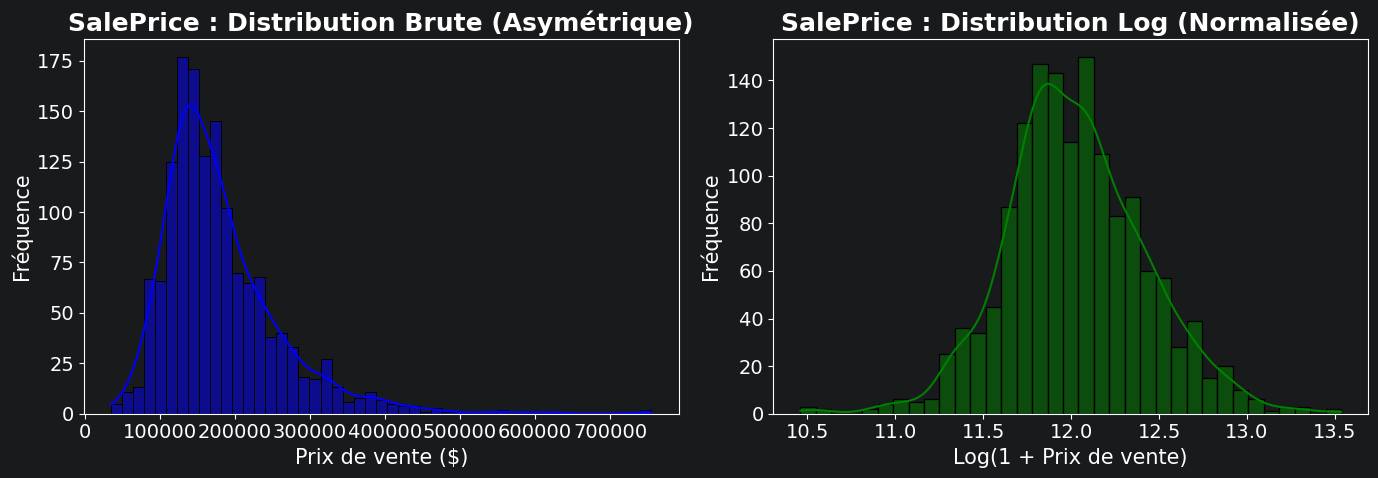

Statistiques après nettoyage et transformation :


,GrLivArea,SalePrice,SalePrice_log
count,1458.000000,1458.000000,1458.000000
mean,1510.465706,180932.919067,12.024015
std,507.878508,79495.055285,0.399713
min,334.000000,34900.000000,10.460271
25%,1128.500000,129925.000000,11.774720
50%,1461.500000,163000.000000,12.001512
75%,1776.000000,214000.000000,12.273736
max,4476.000000,755000.000000,13.534474


In [20]:
# Application de la transformation logarithmique sur la cible
# (Indispensable pour la métrique RMSE sur logs)
# ex: log1p(150 000) = 11.91, log1p(5 000 000) = 15.42
df_cleaned['SalePrice_log'] = np.log1p(df_cleaned['SalePrice'])

# Création d'une figure avec 2 colonnes (1 ligne, 2 graphiques)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Distribution Avant (SalePrice Brut) ---
sns.histplot(df_cleaned['SalePrice'], kde=True, color="blue", ax=ax1)
ax1.set_title("SalePrice : Distribution Brute (Asymétrique)", fontweight='bold')
ax1.set_xlabel("Prix de vente ($)")
ax1.set_ylabel("Fréquence")

# --- Graphique 2 : Distribution Après (SalePrice Log) ---
sns.histplot(df_cleaned['SalePrice_log'], kde=True, color="green", ax=ax2)
ax2.set_title("SalePrice : Distribution Log (Normalisée)", fontweight='bold')
ax2.set_xlabel("Log(1 + Prix de vente)")
ax2.set_ylabel("Fréquence")

# Ajustement pour éviter que les titres ne se chevauchent
plt.tight_layout()
plt.show()

print("Statistiques après nettoyage et transformation :")
display(df_cleaned[['GrLivArea', 'SalePrice', 'SalePrice_log']].describe())

### 3.4 Préparation des données et définition des pipelines

Pour construire un modèle robuste et éviter toute fuite de données, nous adoptons une approche structurée :
Séparation des données : Nous définissons d'abord X (caractéristiques) et y (cible), puis nous les divisons immédiatement en jeux d'entraînement (X_train) et de test (X_test).
Définition des stratégies : Nous analysons X_train pour créer des listes de colonnes distinctes, chacune nécessitant un traitement spécifique.
Pipelines : Ces listes alimenteront un ColumnTransformer qui appliquera le bon traitement à chaque groupe de colonnes, en apprenant les paramètres d'imputation et de mise à l'échelle uniquement sur X_train.
Voici le détail des stratégies appliquées :

a) Variables Numériques

Elles sont divisées en deux groupes :
- Imputation par zéro : Pour les variables où une valeur manquante (NA) signifie une absence (ex: GarageArea), nous remplaçons NA par 0.
- Imputation par la médiane : Pour les autres variables numériques où NA est une vraie valeur manquante (ex: LotFrontage), nous utilisons la médiane (plus robuste aux valeurs extrêmes que la moyenne).

Toutes les variables numériques sont ensuite mises à la même échelle via Standardisation (StandardScaler).

b. Variables Catégorielles

Elles sont divisées en deux types d'encodage :
- Encodage Ordinal (OrdinalEncoder) : Pour les variables où les catégories ont un ordre logique (ex: la qualité Ex > Gd > TA), nous les transformons en nombres qui respectent cet ordre.
- Encodage "One-Hot" (OneHotEncoder) : Pour les variables nominales où il n'y a pas d'ordre (ex: les quartiers), nous créons des colonnes binaires pour éviter que le modèle n'interprète une fausse relation d'ordre.

L'imputation des valeurs manquantes pour les catégories se fait également de manière ciblée :
- Imputation par "None" : Pour les variables où NA signifie l'absence d'un équipement (ex: PoolQC), nous remplaçons NA par la chaîne de caractères "None".
- Imputation par le Mode : Pour les autres, nous remplaçons NA par la valeur la plus fréquente (le mode).

In [39]:
from sklearn.model_selection import train_test_split

# --- 1. Définition de X et y ---
# On définit nos variables de travail à partir du dataframe nettoyé des outliers
X = df_cleaned.drop(columns=['SalePrice', 'SalePrice_log', 'Id'], errors='ignore')
y_log = df_cleaned['SalePrice_log']

# --- 2. Train-Test Split ---
# On sépare les données AVANT toute imputation ou scaling pour éviter la fuite de données
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# --- 3. Définition des groupes de colonnes pour le ColumnTransformer ---
# On se base sur X_train pour identifier les types de colonnes

# Colonnes numériques
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Colonnes catégorielles ordinales (avec un ordre défini)
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]
ordinal_cats = [['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']] * len(ordinal_cols)

# Colonnes catégorielles nominales (sans ordre)
all_cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
nominal_cols = [col for col in all_cat_cols if col not in ordinal_cols]

# --- 4. Sous-groupes pour l'imputation ---

# Numériques : NA signifie 0 (absence de surface, etc.)
num_zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'MasVnrArea'
]
# Numériques : NA est une vraie valeur manquante (on utilisera la médiane)
# On inclut 'LotFrontage' ici, qui sera géré par la médiane
num_median_cols = [col for col in num_cols if col not in num_zero_cols]

# Catégorielles : NA signifie "None" (absence d'équipement)
# On inclut les ordinales ici car leur NA signifie aussi "None"
cat_none_cols = [
    'Alley', 'BsmtFinType1', 'BsmtFinType2', 'BsmtExposure',
    'GarageType', 'GarageFinish', 'Fence', 'MiscFeature', 'MasVnrType'
] + ordinal_cols

# Catégorielles : NA est une vraie valeur manquante (on utilisera le mode)
cat_mode_cols = [col for col in nominal_cols if col not in cat_none_cols]

# Cas particulier : on retire 'Utilities' car quasi-constante et inutile
if 'Utilities' in cat_mode_cols:
    cat_mode_cols.remove('Utilities')

print("Définition de X, y, et des listes de colonnes : TERMINÉ")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Définition de X, y, et des listes de colonnes : TERMINÉ
X_train shape: (1166, 79)
X_test shape: (292, 79)


### 3.5 Construction du preprocessor

Maintenant que nous avons défini nos stratégies pour chaque groupe de colonnes, nous allons les assembler en une seule et même "usine" de retraitement de données à l'aide de ColumnTransformer.

Le principe est le suivant :

Créer des mini-chaînes de traitement (Pipeline) : Pour chaque stratégie (ex: "imputer par la médiane puis mettre à l'échelle"), nous créons un Pipeline qui enchaîne ces deux étapes.

Assigner chaque chaîne à ses colonnes : Le ColumnTransformer agit comme un chef d'orchestre. Il prend chaque mini-chaîne et l'applique uniquement aux colonnes que nous lui avons assignées (ex: num_median_cols).

Centraliser le tout : L'objet final, que nous nommons preprocessor, contient toute cette logique.

En appelant une seule fois preprocessor.fit_transform(X_train), Scikit-learn va automatiquement :
- Apprendre les médianes, les modes et les paramètres de scaling uniquement sur X_train (pas de fuite de données).
- Appliquer toutes les transformations dans le bon ordre.

Lors de la prédiction, un simple preprocessor.transform(X_test) appliquera exactement les mêmes transformations (avec les paramètres appris sur X_train), garantissant la cohérence des données.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# --- Pipeline pour les numériques à imputer par 0 ---
num_zero_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# --- Pipeline pour les numériques à imputer par la médiane ---
num_median_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# --- Pipeline pour les ordinales (NA -> "None") ---
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OrdinalEncoder(categories=ordinal_cats, handle_unknown='use_encoded_value', unknown_value=-1))
])

# --- Pipeline pour les nominales (NA -> "None") ---
nominal_none_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Pipeline pour les nominales (NA -> Mode) ---
nominal_mode_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Assemblage final dans le ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num_zero', num_zero_pipeline, num_zero_cols),
        ('num_median', num_median_pipeline, num_median_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        # On retire les ordinales des nominales pour ne pas les traiter deux fois
        ('nom_none', nominal_none_pipeline, [c for c in cat_none_cols if c not in ordinal_cols]),
        ('nom_mode', nominal_mode_pipeline, cat_mode_cols)
    ],
    remainder='drop' # Ignore les colonnes non spécifiées (comme 'Utilities')
)

# --- Test rapide pour vérifier que le preprocessor fonctionne ---
# Cela va "fitter" les imputers et scalers sur X_train et transformer les données
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Le preprocessor a été créé avec succès !")
print(f"Dimensions de X_train après traitement : {X_train_processed.shape}")
print(f"Dimensions de X_test après traitement : {X_test_processed.shape}")

Le preprocessor a été créé avec succès !
Dimensions de X_train après traitement : (1166, 256)
Dimensions de X_test après traitement : (292, 256)


## Phase 4 : Modèle Baseline - Régression linéaire

On commence avec un modèle basique, une régression linéaire, comme baseline. On utilise statsmodel pour un résumé détaillé du modèle et vérifier ses assomptions.

### 4.1 Vérification des assomptions de la régression linéaire

Pour utiliser la régression linéaire, il convient de vérifier les assomptions suivantes :

- Linéarité du lien entre les variables indépendantes et la variable dépendante
- Les résidus sont distribués de manière normale autour de 0
- Homoscédasticité
- Les résidus ne sont pas structurés
- il n'existe plus d'outliers

Le code suivant (trouvé sur : https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/) fait ça très bien.

In [23]:
from statsmodels.graphics.gofplots import ProbPlot

plt.rc('font', size=14)
plt.rc('figure', titlesize=18)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=18)


def graph(formula, x_range, label=None):
    """
    Helper function for plotting cook's distance lines
    """
    x = np.asarray(x_range, dtype=float)
    eps = np.finfo(float).eps
    x = np.clip(x, eps, 1 - eps)
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')


def diagnostic_plots(X, y, model_fit=None):
    """
    Function to reproduce the 4 base plots of an OLS model in R.

    ---
    Inputs:

    X: A numpy array or pandas dataframe of the features to use in building the linear regression model
    y: A numpy array or pandas series/dataframe of the target variable of the linear regression model

    model_fit [optional]: a statsmodel.api.OLS model after regressing y on X. If not provided, will be
                        generated from X, y
    """

    if model_fit is None:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # create dataframe from X, y for easier plot handling
    dataframe = pd.concat([X, y], axis=1)

    # model values
    model_fitted_y = model_fit.fittedvalues
    # model residuals
    model_residuals = model_fit.resid
    # normalized residuals
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal
    # absolute squared normalized residuals
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    # absolute residuals
    model_abs_resid = np.abs(model_residuals)
    # leverage, from statsmodels internals
    model_leverage = model_fit.get_influence().hat_matrix_diag
    # cook's distance, from statsmodels internals
    model_cooks = model_fit.get_influence().cooks_distance[0]

    plot_lm_1 = plt.figure()
    plot_lm_1.axes[0] = sns.residplot(x=model_fitted_y, y=dataframe.columns[-1], data=dataframe,
                                      lowess=True,
                                      scatter_kws={'alpha': 0.5},
                                      line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

    plot_lm_1.axes[0].set_title('Residuals vs Fitted')
    plot_lm_1.axes[0].set_xlabel('Fitted values')
    plot_lm_1.axes[0].set_ylabel('Residuals');

    # annotations
    abs_resid = model_abs_resid.sort_values(ascending=False)
    abs_resid_top_3 = abs_resid[:3]
    for i in abs_resid_top_3.index:
        plot_lm_1.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_residuals[i]));

    QQ = ProbPlot(model_norm_residuals)
    plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, lw=1)
    plot_lm_2.axes[0].set_title('Normal Q-Q')
    plot_lm_2.axes[0].set_xlabel('Theoretical Quantiles')
    plot_lm_2.axes[0].set_ylabel('Standardized Residuals');

    # annotations
    abs_norm_resid = np.flip(np.argsort(np.abs(model_norm_residuals)), 0)
    abs_norm_resid_top_3 = abs_norm_resid[:3]
    for r, i in enumerate(abs_norm_resid_top_3):
        plot_lm_2.axes[0].annotate(i,
                                   xy=(np.flip(QQ.theoretical_quantiles, 0)[r],
                                       model_norm_residuals[i]));

    plot_lm_3 = plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5);
    sns.regplot(x=model_fitted_y, y=model_norm_residuals_abs_sqrt,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_3.axes[0].set_title('Scale-Location')
    plot_lm_3.axes[0].set_xlabel('Fitted values')
    plot_lm_3.axes[0].set_ylabel('$sqrt{|Standardized Residuals|}$')

    # annotations
    abs_sq_norm_resid = np.flip(np.argsort(model_norm_residuals_abs_sqrt), 0)
    abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
    for i in abs_norm_resid_top_3:
        plot_lm_3.axes[0].annotate(i,
                                   xy=(model_fitted_y[i],
                                       model_norm_residuals_abs_sqrt[i]))

    plot_lm_4 = plt.figure();
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5);
    sns.regplot(x=model_leverage, y=model_norm_residuals,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
    plot_lm_4.axes[0].set_xlim(0, max(model_leverage) + 0.01)
    plot_lm_4.axes[0].set_ylim(-3, 5)
    plot_lm_4.axes[0].set_title('Residuals vs Leverage')
    plot_lm_4.axes[0].set_xlabel('Leverage')
    plot_lm_4.axes[0].set_ylabel('Standardized Residuals');

    # annotations
    leverage_top_3 = np.flip(np.argsort(model_cooks), 0)[:3]
    for i in leverage_top_3:
        plot_lm_4.axes[0].annotate(i,
                                   xy=(model_leverage[i],
                                       model_norm_residuals[i]));

    p = len(model_fit.params)  # number of model parameters
    eps = np.finfo(float).eps
    x_max = min(float(np.nanmax(model_leverage)), 1 - eps)
    cook_x = np.linspace(max(0.001, eps), x_max, 50)
    graph(lambda x: np.sqrt(np.maximum((0.5 * p * (1 - x)) / x, 0)),
          cook_x,
          'Cook\'s distance')  # 0.5 line
    graph(lambda x: np.sqrt(np.maximum((1 * p * (1 - x)) / x, 0)),
          cook_x)  # 1 line
    plot_lm_4.legend(loc='upper right');

### 4.2 Entraînement du modèle et affichage du résumé

In [24]:
# On choisit un sous-ensemble de paramètres pour le modèle baseline
# Car utiliser trop de paramètres peut causer des problèmes de multicolinéarité
import statsmodels.api as sm

base_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

X_base = X_train[base_features]
y_base = y_train_log

# Réinitialise les index pour que la fonction de diagnostic puisse annoter correctement
X_base_reset = X_base.reset_index(drop=True)
y_base_reset = y_base.reset_index(drop=True)

# Calcule le modèle OLS sur les données ré-indexées (réutilisé pour les graphiques de diagnostic)
model_base_for_plots = sm.OLS(y_base_reset, sm.add_constant(X_base_reset)).fit()

# Affichage du résumé du modèle
print(model_base_for_plots.summary())

                            OLS Regression Results                            
Dep. Variable:          SalePrice_log   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     1099.
Date:                Thu, 28 May 2026   Prob (F-statistic):               0.00
Time:                        16:36:09   Log-Likelihood:                 531.59
No. Observations:                1166   AIC:                            -1049.
Df Residuals:                    1159   BIC:                            -1014.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           5.4547      0.403     13.526      

ATTENTION : S'assurer qu'on teste le modèle baseline avec le pipeline complet !!!

#### 4.2.1 Vérification des hypothèses avec les graphiques de diagnostic

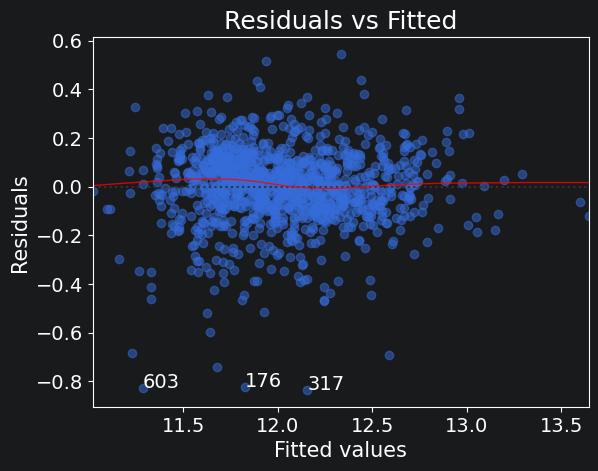

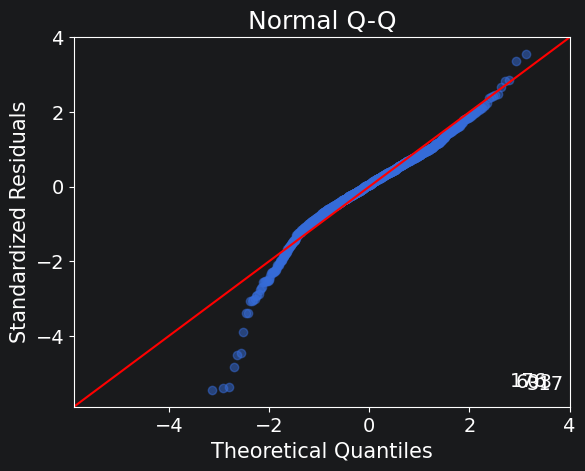

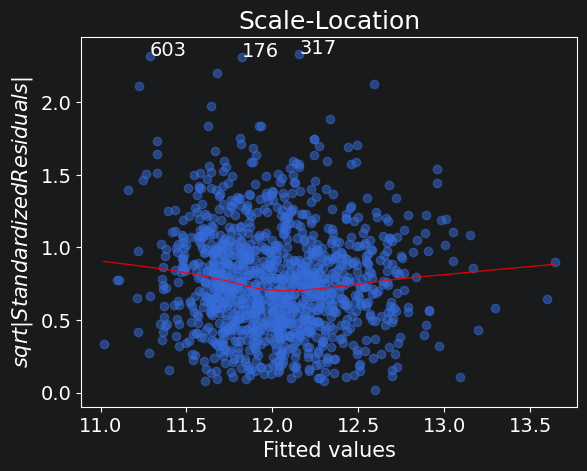

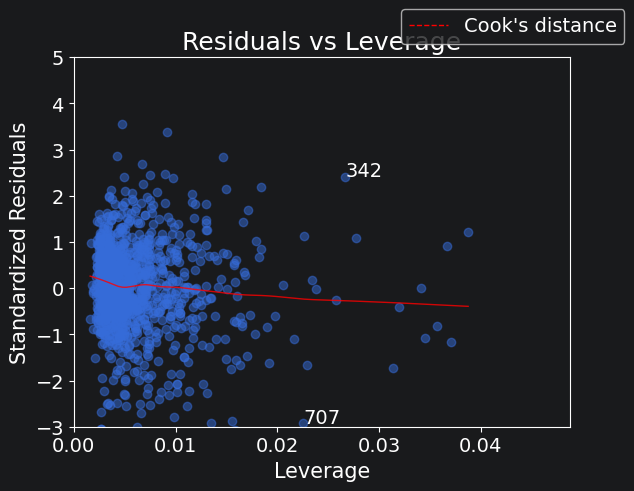

In [25]:
diagnostic_plots(X_base_reset, y_base_reset, model_fit=model_base_for_plots)
plt.show()

### Phase 5 : Élaboration de modèles plus performants

#### 5.1 Entraînement des premiers modèles avancés (Arbres et Boosting)

Maintenant que notre usine de préparation des données (`preprocessor`) est configurée, nous pouvons l'utiliser pour entraîner nos premiers modèles de Machine Learning.

Nous allons encapsuler notre `preprocessor` et notre modèle prédictif au sein d'un **Pipeline global**.

Ainsi, lorsque nous appellerons la méthode `.fit()`, le pipeline se chargera automatiquement d'imputer, de mettre à l'échelle et d'encoder les données avant de les passer au modèle. Lors de l'appel à `.predict()`, les mêmes transformations seront appliquées strictement à l'identique sur les nouvelles données. Nous testons ici deux algorithmes robustes : un Random Forest et un Gradient Boosting.

In [26]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 1. Création des Pipelines complets (Préparation + Modèle)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
])

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

# 2. Entraînement directement sur les données brutes X_train
print("Entraînement du Random Forest en cours...")
rf_pipeline.fit(X_train, y_train_log)

print("Entraînement du Gradient Boosting en cours...")
gb_pipeline.fit(X_train, y_train_log)

# 3. Prédictions sur les données brutes X_test
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_gb = gb_pipeline.predict(X_test)

# 4. Évaluation (Calcul du RMSE)
rmse_rf = np.sqrt(mean_squared_error(y_test_log, y_pred_rf))
rmse_gb = np.sqrt(mean_squared_error(y_test_log, y_pred_gb))

# 5. Affichage des résultats
results_rmse = {
    'Random Forest': rmse_rf,
    'Gradient Boosting': rmse_gb
}

results = pd.DataFrame({
    'Model': list(results_rmse.keys()),
    'RMSE_log': list(results_rmse.values())
})

print("\nPerformances des modèles (RMSE) :")
display(results.sort_values(by='RMSE_log'))

Entraînement du Random Forest en cours...
Entraînement du Gradient Boosting en cours...

Performances des modèles (RMSE) :


,Model,RMSE_log
1,Gradient Boosting,0.119915
0,Random Forest,0.142680


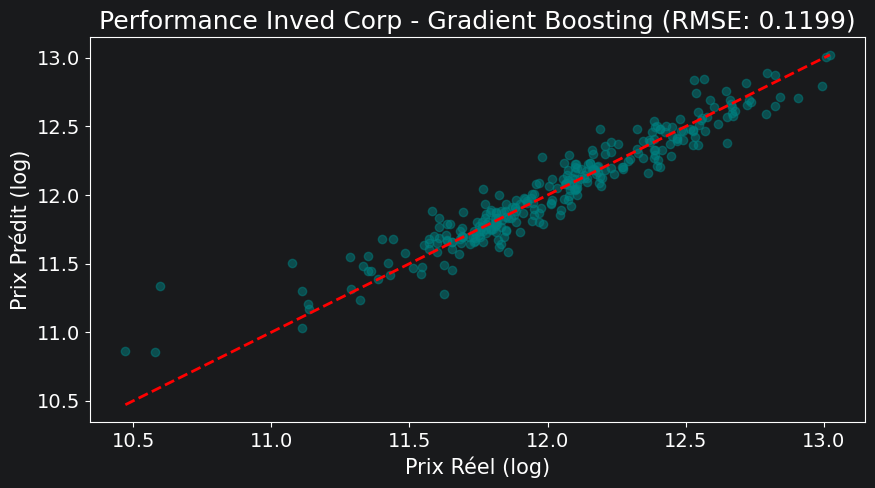

In [27]:
# --- Visualisation des performances du Gradient Boosting ---
# (Utilise y_pred_gb généré par notre pipeline juste avant)
plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_pred_gb, alpha=0.5, color='teal')
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
plt.title(f"Performance Inved Corp - Gradient Boosting (RMSE: {rmse_gb:.4f})")
plt.xlabel("Prix Réel (log)")
plt.ylabel("Prix Prédit (log)")
plt.show()

Optimisation du modèle KNN en cours (cela peut prendre quelques secondes)...


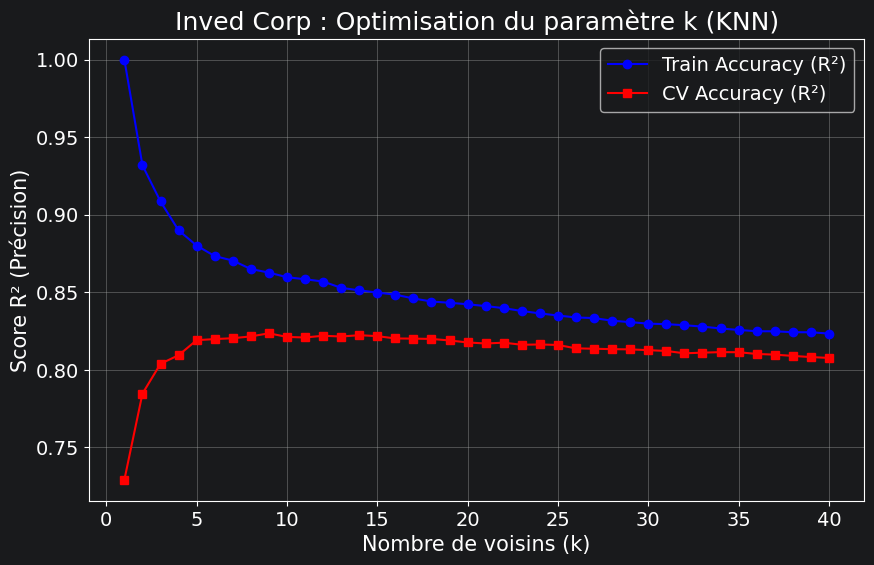

Le meilleur k pour la validation croisée est : 9


In [28]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

# 1. Définir une plage de k (ex: de 1 à 40)
k_range = range(1, 41)
train_scores = []
cv_scores = []

print("Optimisation du modèle KNN en cours (cela peut prendre quelques secondes)...")

# 2. Boucle pour tester chaque valeur de k
for k in k_range:
    # On intègre notre preprocessor global avec le modèle KNN
    knn_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])

    # Score d'entraînement (R²)
    knn_pipeline.fit(X_train, y_train_log)
    train_scores.append(knn_pipeline.score(X_train, y_train_log))

    # Score de Validation Croisée (CV) - Moyenne de 5-folds
    scores = cross_val_score(knn_pipeline, X_train, y_train_log, cv=5)
    cv_scores.append(scores.mean())

# 3. Visualisation des "Accuracies" (R² Score)
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, label='Train Accuracy (R²)', color='blue', marker='o')
plt.plot(k_range, cv_scores, label='CV Accuracy (R²)', color='red', marker='s')

plt.title('Inved Corp : Optimisation du paramètre k (KNN)')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Score R² (Précision)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Identifier le meilleur k
best_k = k_range[np.argmax(cv_scores)]
print(f"Le meilleur k pour la validation croisée est : {best_k}")

#### 5.2 Déploiement de l'artillerie lourde : Ensembles et Stacking

Pour pousser les performances de notre modèle encore plus loin, nous faisons appel à des algorithmes d'ensemble avancés : **AdaBoost**, l'incontournable **XGBoost**, et une architecture de **Stacking**. Le Stacking est particulièrement puissant car il combine les prédictions de plusieurs modèles (Random Forest, Gradient Boosting, XGBoost) et laisse un "méta-modèle" (ici un RidgeCV) décider comment les pondérer de manière optimale.

Toujours dans notre logique d'ingénierie robuste (Mise en production), **chaque modèle est encapsulé dans notre Pipeline global**. Ainsi, même une architecture complexe comme le Stacking recevra des données parfaitement standardisées et imputées, évitant tout risque de fuite de données lors de la validation.

Début de l'évaluation des modèles avancés pour InVed Corp...
SUCCÈS ! Random Forest terminé. RMSE : 0.1427
SUCCÈS ! AdaBoost terminé. RMSE : 0.1657
SUCCÈS ! XGBoost terminé. RMSE : 0.1274
SUCCÈS ! Stacking terminé. RMSE : 0.1202


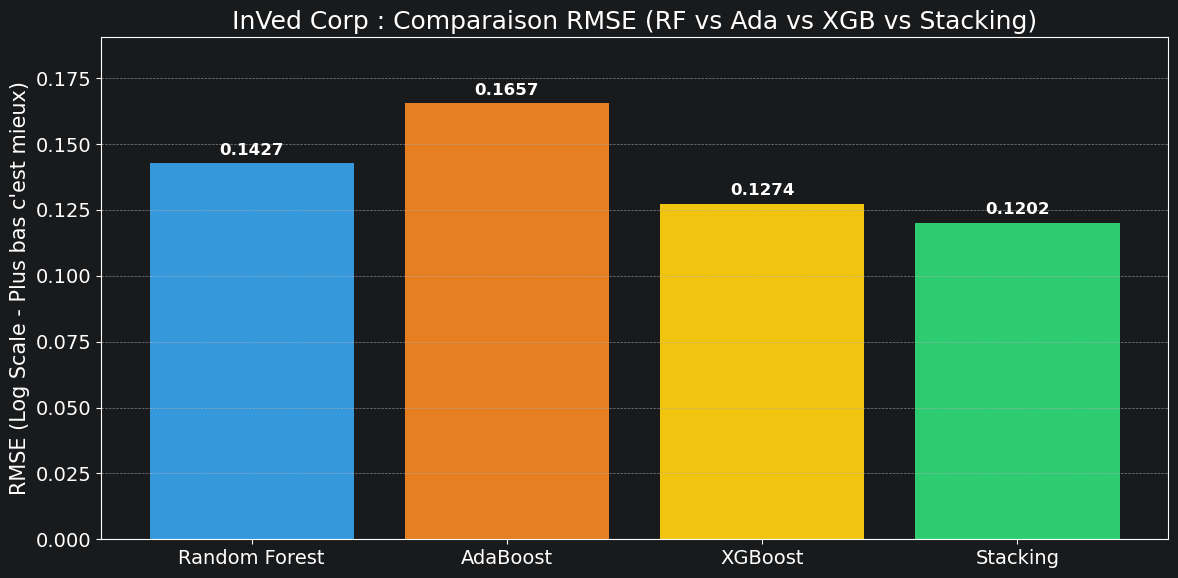

In [29]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, StackingRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

# --- 1. Définition des modèles de base ---

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)

# Modèle 4 : Stacking (L'ensemble combiné)
# Les estimateurs internes recevront les données déjà nettoyées car on va mettre TOUT le Stacking dans un Pipeline
estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42))
]
stack_model = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())

# --- 2. Assemblage avec le Preprocessor (Pipelines) ---

# On associe chaque modèle à notre usine de traitement (preprocessor)
pipelines = {
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor), ('model', rf_model)]),
    'AdaBoost': Pipeline(steps=[('preprocessor', preprocessor), ('model', ada_model)]),
    'XGBoost': Pipeline(steps=[('preprocessor', preprocessor), ('model', xgb_model)]),
    'Stacking': Pipeline(steps=[('preprocessor', preprocessor), ('model', stack_model)])
}

results_rmse = {}

# --- 3. Entraînement et Évaluation ---

print("Début de l'évaluation des modèles avancés pour InVed Corp...")
for name, pipe in pipelines.items():
    # Le pipeline s'occupe de tout : nettoyage de X_train puis entraînement du modèle
    pipe.fit(X_train, y_train_log)

    # Le pipeline s'occupe de tout : nettoyage de X_test puis prédiction
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test_log, preds))
    results_rmse[name] = rmse
    print(f"SUCCÈS ! {name} terminé. RMSE : {rmse:.4f}")

# --- 4. Visualisation de la performance ---

plt.figure(figsize=(12, 6))
colors = ['#3498db', '#e67e22', '#f1c40f', '#2ecc71']
bars = plt.bar(results_rmse.keys(), results_rmse.values(), color=colors)

plt.title('InVed Corp : Comparaison RMSE (RF vs Ada vs XGB vs Stacking)')
plt.ylabel('RMSE (Log Scale - Plus bas c\'est mieux)')

# Ajuster l'axe Y pour avoir de la place pour le texte
plt.ylim(0, max(results_rmse.values()) * 1.15)

# Ajout des étiquettes de score sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 4),
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 5.3 Modèles Linéaires Régularisés (Ridge, Lasso, ElasticNet)

Bien que les algorithmes d'arbres (comme Random Forest ou XGBoost) soient très puissants, les modèles linéaires avec pénalité (régularisation) restent des incontournables. Ils sont particulièrement efficaces lorsque le jeu de données comporte de nombreuses variables fortement corrélées.

Nous testons ici **Ridge**, **Lasso** et **ElasticNet**. L'avantage majeur du Lasso est sa capacité à faire de la sélection de variables (Feature Selection) en réduisant le coefficient des variables inutiles à zéro.
Encore une fois, ces algorithmes intègrent notre `preprocessor` global afin de garantir une mise à l'échelle parfaite, condition *sine qua non* pour que les modèles de régularisation fonctionnent correctement. Nous utilisons les versions `CV` (Cross-Validation) de Scikit-Learn pour optimiser automatiquement leurs hyperparamètres internes.


--- Évaluation des modèles de régularisation linéaire ---
SUCCÈS ! Lasso terminé. RMSE : 0.1169
SUCCÈS ! Ridge terminé. RMSE : 0.1226
SUCCÈS ! ElasticNet terminé. RMSE : 0.1169


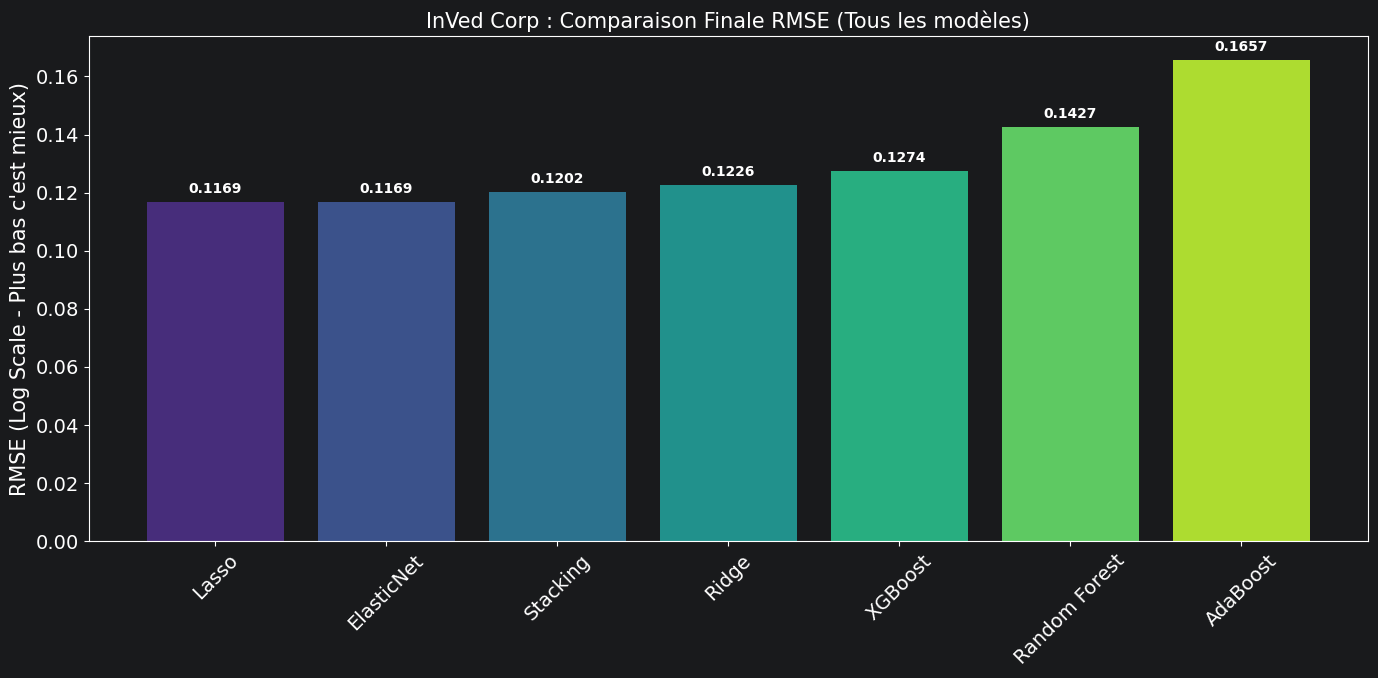


--- Analyse de Robustesse (Lasso) ---
Variables totales créées par l'encodage : 256
Variables ignorées (Coef = 0) : 145
Variables conservées comme pertinentes : 111

Top 10 des variables les plus déterminantes pour le prix :


,Feature,Importance
93,nom_mode__MSZoning_C (all),0.227695
20,num_median__GrLivArea,0.123933
122,nom_mode__Neighborhood_Crawfor,0.104360
138,nom_mode__Neighborhood_StoneBr,0.099771
186,nom_mode__Exterior1st_BrkFace,0.083504
237,nom_mode__Functional_Typ,0.065349
13,num_median__OverallQual,0.065061
247,nom_mode__SaleType_New,0.059898
15,num_median__YearBuilt,0.057627
223,nom_mode__Heating_Grav,0.055330


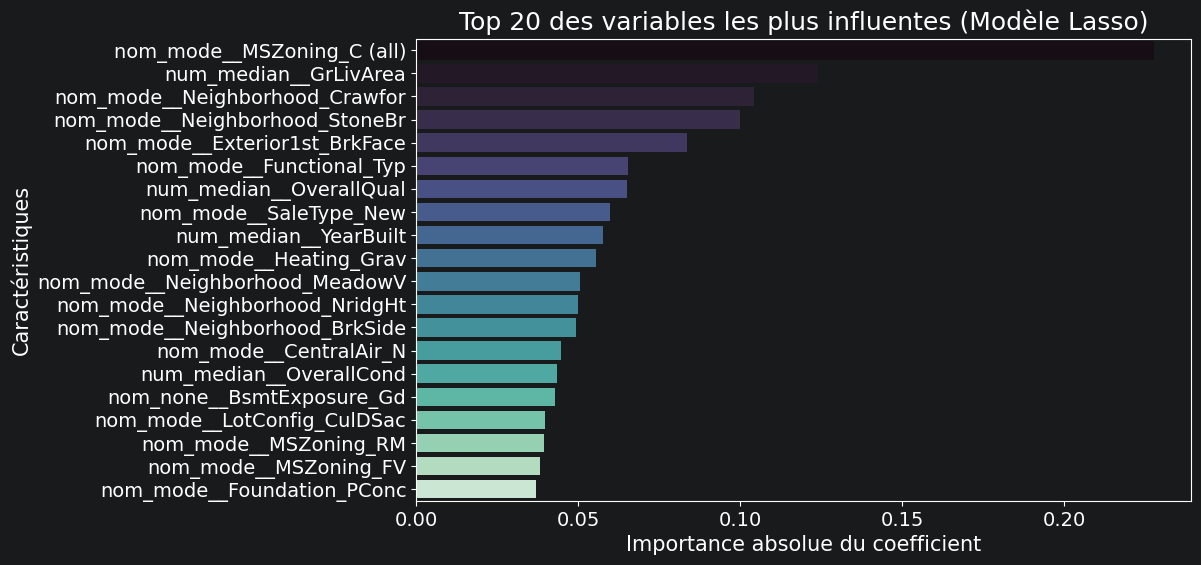

In [30]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
import seaborn as sns

# --- 1. Définition des modèles ---
lasso_model = LassoCV(alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50000, random_state=42)
ridge_model = RidgeCV(alphas=np.logspace(-2, 2, 20), cv=5)
elastic_model = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                             alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50000, random_state=42)

# --- 2. Assemblage avec le Preprocessor (Pipelines) ---
new_pipelines = {
    'Lasso': Pipeline(steps=[('preprocessor', preprocessor), ('model', lasso_model)]),
    'Ridge': Pipeline(steps=[('preprocessor', preprocessor), ('model', ridge_model)]),
    'ElasticNet': Pipeline(steps=[('preprocessor', preprocessor), ('model', elastic_model)])
}

print("\n--- Évaluation des modèles de régularisation linéaire ---")

for name, pipe in new_pipelines.items():
    pipe.fit(X_train, y_train_log)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_log, preds))
    results_rmse[name] = rmse  # Ajout au dictionnaire global contenant déjà RF, XGBoost, etc.
    print(f"SUCCÈS ! {name} terminé. RMSE : {rmse:.4f}")

# --- 3. Visualisation comparative GLOBALE ---
plt.figure(figsize=(14, 7))

# Tri de tous les résultats (du meilleur RMSE au moins bon)
sorted_results = dict(sorted(results_rmse.items(), key=lambda item: item[1]))

colors = sns.color_palette("viridis", len(sorted_results))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), color=colors)

plt.title('InVed Corp : Comparaison Finale RMSE (Tous les modèles)', fontsize=15)
plt.ylabel('RMSE (Log Scale - Plus bas c\'est mieux)')
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 4),
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- 4. Analyse des variables sélectionnées par le Lasso ---

# On récupère le modèle Lasso entraîné depuis le pipeline
lasso_final = new_pipelines['Lasso'].named_steps['model']

# On récupère les VRAIS noms des colonnes générées par le preprocessor (après encodage)
feature_names = new_pipelines['Lasso'].named_steps['preprocessor'].get_feature_names_out()

n_zero = np.sum(lasso_final.coef_ == 0)
n_total = len(lasso_final.coef_)

print(f"\n--- Analyse de Robustesse (Lasso) ---")
print(f"Variables totales créées par l'encodage : {n_total}")
print(f"Variables ignorées (Coef = 0) : {n_zero}")
print(f"Variables conservées comme pertinentes : {n_total - n_zero}")

# Top 10 des variables les plus importantes
coef_importance = pd.DataFrame({
    'Feature': feature_names, # Utilisation des vrais noms générés
    'Importance': np.abs(lasso_final.coef_)
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 des variables les plus déterminantes pour le prix :")
display(coef_importance.head(10))

# Visualisation des coefficients
plt.figure(figsize=(10, 6))
# On utilise sns.barplot pour un rendu plus propre que la méthode pandas native
sns.barplot(data=coef_importance.head(20), x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title("Top 20 des variables les plus influentes (Modèle Lasso)")
plt.xlabel("Importance absolue du coefficient")
plt.ylabel("Caractéristiques")
plt.show()

#### 5.4 Optimisation des Hyperparamètres (GridSearchCV)

Jusqu'à présent, nous avons utilisé nos modèles avec des paramètres choisis arbitrairement (ou par défaut). Pour extraire le maximum de performance de notre meilleur algorithme, nous devons trouver la combinaison parfaite de ses hyperparamètres.

Nous utilisons `GridSearchCV`, qui va tester systématiquement plusieurs combinaisons grâce à la validation croisée, tout en conservant notre `Pipeline` pour garantir l'intégrité des données à chaque test.

In [31]:
from sklearn.model_selection import GridSearchCV

# 1. On redéfinit un pipeline vierge pour XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

# 2. Définition de la grille de paramètres à tester
# Attention : comme le modèle est dans un pipeline, il faut préfixer les paramètres par 'model__'
param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 4, 5]
}

print("Lancement de la recherche par quadrillage (GridSearchCV)... Cela peut prendre quelques minutes.")

# 3. Lancement du GridSearch (n_jobs=-1 utilise tous les cœurs de votre processeur)
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train_log)

# 4. Récupération et test du meilleur modèle
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_best))

print(f"\n--- Résultats de l'optimisation ---")
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Nouveau score RMSE sur le jeu de test : {best_rmse:.4f}")

# On stocke ce modèle champion pour la suite
results_rmse['XGBoost Optimisé'] = best_rmse

Lancement de la recherche par quadrillage (GridSearchCV)... Cela peut prendre quelques minutes.
Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- Résultats de l'optimisation ---
Meilleurs hyperparamètres : {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300}
Nouveau score RMSE sur le jeu de test : 0.1201


#### 5.5 Interprétabilité Métier : Les Valeurs de Shapley (SHAP)

Avoir un modèle performant est une chose, mais pouvoir expliquer ses décisions en est une autre. Dans notre contexte (mise en production chez InVed Corp), il est crucial de pouvoir justifier à un client ou à un agent immobilier pourquoi le modèle prédit un certain prix.

Pour cela, nous utilisons la théorie des jeux avec les **Valeurs de Shapley**. La librairie `shap` nous permet de calculer exactement comment chaque variable (surface, quartier, qualité) a poussé la prédiction du prix vers le haut ou vers le bas.

Calcul des valeurs SHAP en cours...


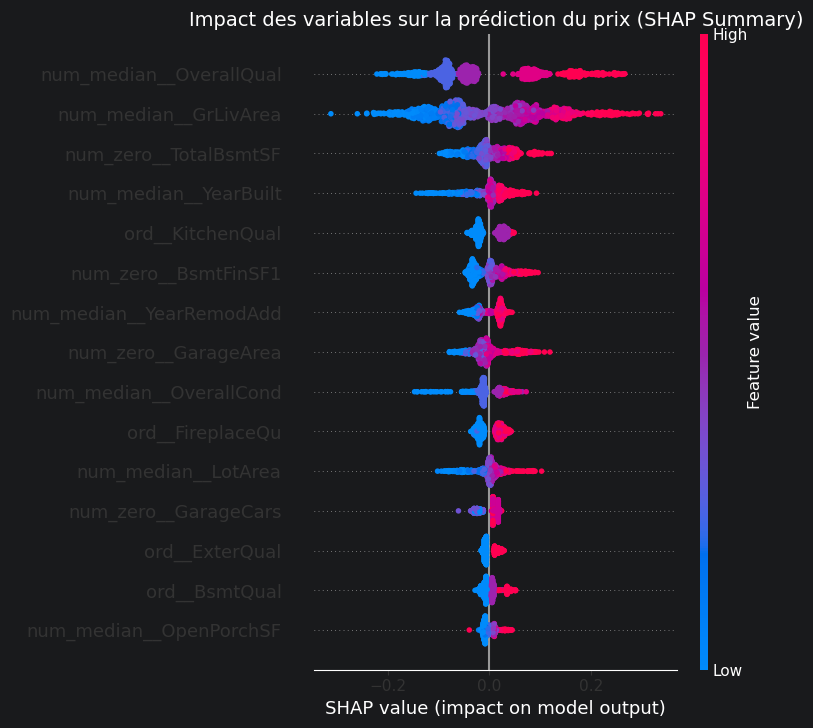

In [32]:
import shap

print("Calcul des valeurs SHAP en cours...")

# 1. Extraction du meilleur modèle XGBoost depuis notre pipeline champion
xgb_final = best_model.named_steps['model']

# 2. Extraction du preprocessor et transformation de X_train pour SHAP
preprocessor_final = best_model.named_steps['preprocessor']
X_train_transformed = preprocessor_final.transform(X_train)

# 3. Récupération du vrai nom des colonnes (générées par le OneHotEncoder)
feature_names = preprocessor_final.get_feature_names_out()

# Convertir la matrice transformée en DataFrame Pandas pour un bel affichage dans SHAP
X_train_shap = pd.DataFrame(X_train_transformed, columns=feature_names)

# 4. Initialisation de l'explainer SHAP pour les arbres
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_train_shap)

# 5. Affichage du Summary Plot (L'impact global des variables)
plt.figure(figsize=(10, 8))
plt.title("Impact des variables sur la prédiction du prix (SHAP Summary)", fontsize=14)
shap.summary_plot(shap_values, X_train_shap, max_display=15)